In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/fasgadhsxnzmjj/mmd-dataset/centralVN_dataWeather.csv
/kaggle/input/datasets/fasgadhsxnzmjj/mmd-dataset/northVN_dataThoiTiet.csv
/kaggle/input/datasets/fasgadhsxnzmjj/mmd-dataset/southVN_dataAIR.csv
/kaggle/input/datasets/fasgadhsxnzmjj/mmd-dataset/southVN_dataWeather.csv
/kaggle/input/datasets/fasgadhsxnzmjj/mmd-dataset/centralVN_dataAIR.csv
/kaggle/input/datasets/fasgadhsxnzmjj/mmd-dataset/northVN_dataAIR.csv


In [2]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

import matplotlib.pyplot as plt

2026-04-19 08:13:54.045304: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776586434.320410      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776586434.396405      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776586435.053408      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776586435.053462      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776586435.053466      55 computation_placer.cc:177] computation placer alr

# 1.Load data

In [3]:
# AIR data
df_air = pd.read_csv('/kaggle/input/datasets/fasgadhsxnzmjj/mmd-dataset/northVN_dataAIR.csv')

# MET data (weather)
df_wea = pd.read_csv('/kaggle/input/datasets/fasgadhsxnzmjj/mmd-dataset/northVN_dataThoiTiet.csv')

In [4]:
df_air = df_air[df_air['city'] == 'Ha Noi']
df_wea = df_wea[df_wea['city'] == 'Ha Noi']

In [5]:
df_air.head()

,district,city,time,pm10 (μg/m³),pm2_5 (μg/m³),carbon_monoxide (μg/m³),carbon_dioxide (ppm),nitrogen_dioxide (μg/m³),sulphur_dioxide (μg/m³),ozone (μg/m³),aerosol_optical_depth (),dust (μg/m³),uv_index (),uv_index_clear_sky ()
0,Ba Dinh,Ha Noi,2022-08-04T00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Ba Dinh,Ha Noi,2022-08-04T01:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Ba Dinh,Ha Noi,2022-08-04T02:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Ba Dinh,Ha Noi,2022-08-04T03:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Ba Dinh,Ha Noi,2022-08-04T04:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df_wea.head()

,district,city,time,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),rain (mm),cloud_cover (%),cloud_cover_low (%),...,wind_speed_100m (km/h),wind_direction_10m (°),soil_temperature_0_to_7cm (°C),soil_temperature_7_to_28cm (°C),soil_temperature_28_to_100cm (°C),soil_temperature_100_to_255cm (°C),soil_moisture_0_to_7cm (m³/m³),soil_moisture_7_to_28cm (m³/m³),soil_moisture_28_to_100cm (m³/m³),soil_moisture_100_to_255cm (m³/m³)
0,Ba Dinh,Ha Noi,2016-01-01T00:00,15.1,80,15.1,0.0,0.0,99,97,...,5.4,347,15.9,16.9,19.8,24.3,0.373,0.375,0.359,0.386
1,Ba Dinh,Ha Noi,2016-01-01T01:00,14.9,82,15.1,0.0,0.0,99,98,...,5.4,353,15.8,16.9,19.8,24.3,0.372,0.375,0.359,0.386
2,Ba Dinh,Ha Noi,2016-01-01T02:00,15.0,81,15.2,0.0,0.0,99,98,...,6.2,360,15.8,16.9,19.8,24.3,0.372,0.375,0.359,0.386
3,Ba Dinh,Ha Noi,2016-01-01T03:00,15.1,76,14.9,0.0,0.0,98,97,...,7.0,8,15.8,16.9,19.8,24.3,0.372,0.375,0.359,0.386
4,Ba Dinh,Ha Noi,2016-01-01T04:00,14.7,78,14.6,0.0,0.0,95,92,...,7.1,14,15.6,16.8,19.8,24.3,0.372,0.374,0.359,0.386


# 2.Data cleaning

In [7]:
# chuẩn hóa tên cột
import re

def clean_columns(df):
    df.columns = [
        re.sub(r'\s*\([^)]*\)', '', col)  # xóa đơn vị
        .strip()
        .lower()
        .replace(' ', '_')
        for col in df.columns
    ]
    return df

df_air = clean_columns(df_air)
df_wea = clean_columns(df_wea)

print(df_air.columns)
print(df_wea.columns)

Index(['district', 'city', 'time', 'pm10', 'pm2_5', 'carbon_monoxide',
       'carbon_dioxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone',
       'aerosol_optical_depth', 'dust', 'uv_index', 'uv_index_clear_sky'],
      dtype='object')
Index(['district', 'city', 'time', 'temperature_2m', 'relative_humidity_2m',
       'apparent_temperature', 'precipitation', 'rain', 'cloud_cover',
       'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high',
       'wind_speed_10m', 'wind_speed_100m', 'wind_direction_10m',
       'soil_temperature_0_to_7cm', 'soil_temperature_7_to_28cm',
       'soil_temperature_28_to_100cm', 'soil_temperature_100_to_255cm',
       'soil_moisture_0_to_7cm', 'soil_moisture_7_to_28cm',
       'soil_moisture_28_to_100cm', 'soil_moisture_100_to_255cm'],
      dtype='object')


In [8]:
# chuẩn hóa cột time
df_air['time'] = pd.to_datetime(df_air['time'])
df_wea['time'] = pd.to_datetime(df_wea['time'])

In [9]:
# đưa về cùng thời gian để gộp
start_time = max(df_air['time'].min(), df_wea['time'].min())
end_time = min(df_air['time'].max(), df_wea['time'].max())

df_air = df_air[(df_air['time'] >= start_time) & (df_air['time'] <= end_time)]
df_wea = df_wea[(df_wea['time'] >= start_time) & (df_wea['time'] <= end_time)]

print(start_time, end_time)

2022-08-04 00:00:00 2026-02-01 23:00:00


In [10]:
# gộp 2 bảng
df = pd.merge(
    df_air,
    df_wea,
    on=['time', 'city', 'district'],
    how='inner'
)

print(df.shape)

(920160, 34)


In [11]:
# chọn ra những cột quan trọng
selected_columns = [
    'district', 'city', 'time',

    # pollutants
    'pm2_5', 'pm10',
    'carbon_monoxide',
    'nitrogen_dioxide',
    'sulphur_dioxide',
    'ozone',

    # weather
    'temperature_2m',
    'relative_humidity_2m',
    'rain',
    'wind_speed_10m'
]

df = df[selected_columns]

print(df.shape)

(920160, 13)


In [12]:
df.isnull().sum()

district                  0
city                      0
time                      0
pm2_5                   210
pm10                    210
carbon_monoxide         210
nitrogen_dioxide        210
sulphur_dioxide         210
ozone                   210
temperature_2m            0
relative_humidity_2m      0
rain                      0
wind_speed_10m            0
dtype: int64

In [13]:
df = df.dropna(subset=['pm2_5', 'pm10', 'carbon_monoxide','nitrogen_dioxide','sulphur_dioxide','ozone'])

In [14]:
# tính chỉ số AQI
def calculate_aqi(pm25):
    if pm25 <= 12.0:
        return (50.0 / 12.0) * pm25
    elif pm25 <= 35.4:
        return (49.0 / 23.4) * (pm25 - 12.0) + 51
    elif pm25 <= 55.4:
        return (49.0 / 19.9) * (pm25 - 35.4) + 101
    elif pm25 <= 150.4:
        return (49.0 / 94.9) * (pm25 - 55.4) + 151
    elif pm25 <= 250.4:
        return (99.0 / 99.9) * (pm25 - 150.4) + 201
    elif pm25 <= 350.4:
        return (99.0 / 99.9) * (pm25 - 250.4) + 301
    elif pm25 <= 500.4:
        return (99.0 / 149.9) * (pm25 - 350.4) + 401
    else:
        return 500

df['aqi'] = df['pm2_5'].apply(calculate_aqi)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 919950 entries, 7 to 920159
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   district              919950 non-null  object        
 1   city                  919950 non-null  object        
 2   time                  919950 non-null  datetime64[ns]
 3   pm2_5                 919950 non-null  float64       
 4   pm10                  919950 non-null  float64       
 5   carbon_monoxide       919950 non-null  float64       
 6   nitrogen_dioxide      919950 non-null  float64       
 7   sulphur_dioxide       919950 non-null  float64       
 8   ozone                 919950 non-null  float64       
 9   temperature_2m        919950 non-null  float64       
 10  relative_humidity_2m  919950 non-null  int64         
 11  rain                  919950 non-null  float64       
 12  wind_speed_10m        919950 non-null  float64       
 13  aqi 

In [16]:
df = df.sort_values(['city', 'district', 'time']).reset_index(drop=True)
df.head()

,district,city,time,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,temperature_2m,relative_humidity_2m,rain,wind_speed_10m,aqi
0,Ba Dinh,Ha Noi,2022-08-04 07:00:00,40.3,58.0,595.0,29.7,16.8,24.0,28.5,87,0.0,4.8,113.065327
1,Ba Dinh,Ha Noi,2022-08-04 08:00:00,30.0,43.5,552.0,25.0,18.2,49.0,29.5,82,0.0,2.2,88.692308
2,Ba Dinh,Ha Noi,2022-08-04 09:00:00,32.7,47.3,492.0,18.4,20.2,84.0,30.4,80,0.0,1.3,94.346154
3,Ba Dinh,Ha Noi,2022-08-04 10:00:00,34.9,50.3,429.0,11.2,22.0,128.0,31.8,73,0.0,4.6,98.952991
4,Ba Dinh,Ha Noi,2022-08-04 11:00:00,38.3,55.2,414.0,8.6,21.5,154.0,32.5,71,0.0,4.3,108.140704


In [17]:
# time feature
df['hour'] = df['time'].dt.hour
df['dayofweek'] = df['time'].dt.dayofweek

# lag
df['aqi_lag1'] = df['aqi'].shift(1)
df['aqi_lag3'] = df['aqi'].shift(3)
df['aqi_lag6'] = df['aqi'].shift(6)
df['aqi_lag24'] = df['aqi'].shift(24)

df = df.dropna()

In [18]:
df.shape

(919926, 20)

In [19]:
df.isnull().sum()

district                0
city                    0
time                    0
pm2_5                   0
pm10                    0
carbon_monoxide         0
nitrogen_dioxide        0
sulphur_dioxide         0
ozone                   0
temperature_2m          0
relative_humidity_2m    0
rain                    0
wind_speed_10m          0
aqi                     0
hour                    0
dayofweek               0
aqi_lag1                0
aqi_lag3                0
aqi_lag6                0
aqi_lag24               0
dtype: int64

# 3. Model

## Chọn feature

In [27]:
features = [
    'pm10','carbon_monoxide','nitrogen_dioxide','sulphur_dioxide','ozone',
    
    'temperature_2m','relative_humidity_2m','wind_speed_10m','rain',
    
    'aqi_lag1','aqi_lag3','aqi_lag6','aqi_lag24',
    
    'hour','dayofweek'
]

target = 'aqi'

## Scale data

In [28]:
scaler_x = StandardScaler()
scaler_y = StandardScaler()

df[features] = scaler_x.fit_transform(df[features])
df[[target]] = scaler_y.fit_transform(df[[target]])

## Train test split

In [29]:
split = int(len(df)*0.8)

train = df.iloc[:split]
test  = df.iloc[split:]

## Tạo SEQUENCE (MULTI-STEP)

In [30]:
def create_sequences_multi(data, features, target, window=24, horizon=24):
    x, y = [], []

    values = data[features + [target]].values

    for i in range(len(values) - window - horizon):
        x.append(values[i:i+window, :-1])
        y.append(values[i+window:i+window+horizon, -1])

    return np.array(x), np.array(y)

x_train, y_train = create_sequences_multi(train, features, target)
x_test, y_test = create_sequences_multi(test, features, target)

print("x_train:", x_train.shape)
print("y_train:", y_train.shape)

x_train: (735892, 24, 15)
y_train: (735892, 24)


## Buid model LSTM

In [31]:
model = Sequential([
    LSTM(128, return_sequences=True),
    LSTM(64),
    Dense(24)
])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

2026-04-19 08:21:13.793348: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## Train

In [32]:
model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=10,
    batch_size=128
)

Epoch 1/10
5750/5750 ━━━━━━━━━━━━━━━━━━━━ 412s 71ms/step - loss: 0.3205 - mae: 0.4276 - val_loss: 0.1482 - val_mae: 0.2901
Epoch 2/10
5750/5750 ━━━━━━━━━━━━━━━━━━━━ 414s 72ms/step - loss: 0.1006 - mae: 0.2381 - val_loss: 0.1054 - val_mae: 0.2431
Epoch 3/10
5750/5750 ━━━━━━━━━━━━━━━━━━━━ 425s 74ms/step - loss: 0.0703 - mae: 0.1989 - val_loss: 0.0866 - val_mae: 0.2211
Epoch 4/10
5750/5750 ━━━━━━━━━━━━━━━━━━━━ 423s 73ms/step - loss: 0.0574 - mae: 0.1796 - val_loss: 0.0750 - val_mae: 0.2053
Epoch 5/10
5750/5750 ━━━━━━━━━━━━━━━━━━━━ 422s 73ms/step - loss: 0.0496 - mae: 0.1670 - val_loss: 0.0684 - val_mae: 0.1960
Epoch 6/10
5750/5750 ━━━━━━━━━━━━━━━━━━━━ 422s 73ms/step - loss: 0.0449 - mae: 0.1587 - val_loss: 0.0623 - val_mae: 0.1870
Epoch 7/10
5750/5750 ━━━━━━━━━━━━━━━━━━━━ 419s 73ms/step - loss: 0.0415 - mae: 0.1525 - val_loss: 0.0589 - val_mae: 0.1822
Epoch 8/10
5750/5750 ━━━━━━━━━━━━━━━━━━━━ 420s 73ms/step - loss: 0.0388 - mae: 0.1476 - val_loss: 0.0561 - val_mae: 0.1785
Epoch 9/10
5750/

## Evaluate

In [33]:
pred = model.predict(x_test)

# inverse scale
y_test_inv = scaler_y.inverse_transform(y_test.reshape(-1,1)).reshape(y_test.shape)
pred_inv = scaler_y.inverse_transform(pred.reshape(-1,1)).reshape(pred.shape)

mae = mean_absolute_error(y_test_inv.flatten(), pred_inv.flatten())
mse = mean_squared_error(y_test_inv.flatten(), pred_inv.flatten())

print("MAE:", mae)
print("MSE:", mse)

5749/5749 ━━━━━━━━━━━━━━━━━━━━ 76s 13ms/step
MAE: 6.741509986500228
MSE: 80.41715303058695


## Visualize

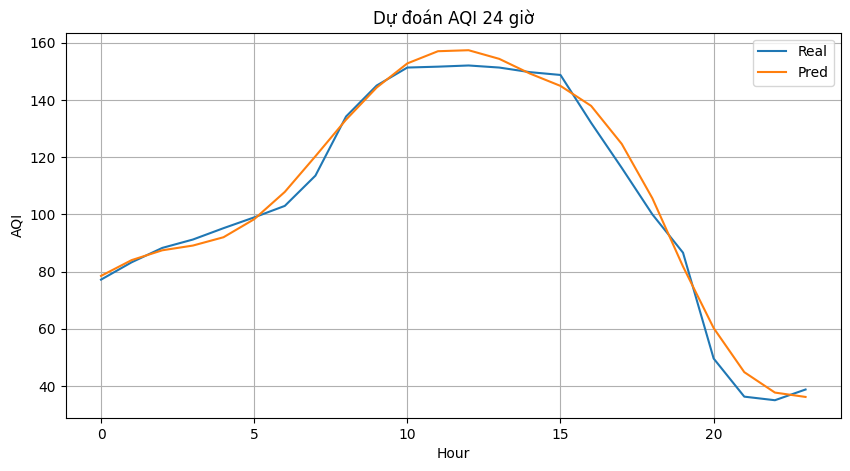

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(y_test_inv[0], label="Real")
plt.plot(pred_inv[0], label="Pred")

plt.title("Dự đoán AQI 24 giờ")
plt.xlabel("Hour")
plt.ylabel("AQI")

plt.legend()
plt.grid()

plt.show()

## Lưu model

In [36]:
import joblib
model.save('lstm_model.h5')
joblib.dump(scaler_x, 'scaler_x.pkl')
joblib.dump(scaler_y, 'scaler_y.pkl')
joblib.dump(df, 'data.pkl')

['data.pkl']